# AQI Predictor -- Exploratory Data Analysis



In [20]:
from pathlib import Path

PROJECT_ROOT = Path(r"C:\Users\warda\Downloads\aqi-predictor-v4")

print("CSV files found:")
for file in PROJECT_ROOT.rglob("*.csv"):
    print(file)

CSV files found:
C:\Users\warda\Downloads\aqi-predictor-v4\analytics\aqi_categories.csv
C:\Users\warda\Downloads\aqi-predictor-v4\analytics\city_comparison.csv
C:\Users\warda\Downloads\aqi-predictor-v4\analytics\city_statistics.csv
C:\Users\warda\Downloads\aqi-predictor-v4\analytics\daily_aqi.csv
C:\Users\warda\Downloads\aqi-predictor-v4\analytics\model_performance.csv
C:\Users\warda\Downloads\aqi-predictor-v4\analytics\monthly_aqi.csv
C:\Users\warda\Downloads\aqi-predictor-v4\analytics\pollutant_statistics.csv
C:\Users\warda\Downloads\aqi-predictor-v4\analytics\prediction_analysis.csv
C:\Users\warda\Downloads\aqi-predictor-v4\venv\Lib\site-packages\tornado\test\csv_translations\fr_FR.csv
C:\Users\warda\Downloads\aqi-predictor-v4\venv\Lib\site-packages\sklearn\datasets\data\breast_cancer.csv
C:\Users\warda\Downloads\aqi-predictor-v4\venv\Lib\site-packages\sklearn\datasets\data\iris.csv
C:\Users\warda\Downloads\aqi-predictor-v4\venv\Lib\site-packages\sklearn\datasets\data\linnerud_exerc

In [22]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# PROJECT PATH
# ============================================================

PROJECT_ROOT = Path(r"C:\Users\warda\Downloads\aqi-predictor-v4")

DATA_PATH = PROJECT_ROOT / "analytics" / "daily_aqi.csv"

print("Loading:")
print(DATA_PATH)
print("Exists:", DATA_PATH.exists())

# ============================================================
# LOAD DATA
# ============================================================

df = pd.read_csv(DATA_PATH)

# Convert date
df["date"] = pd.to_datetime(
    df["date"],
    errors="coerce"
)

# Sort
df = df.sort_values(
    ["city_name", "date"]
).reset_index(drop=True)

print()
print("=" * 70)
print("DAILY AQI DATASET")
print("=" * 70)

print("Shape:", df.shape)

print()
print("Columns:")
print(df.columns.tolist())

print()
print("Cities:")
print(df["city_name"].unique())

print()
print("Date range:")
print(df["date"].min(), "→", df["date"].max())

print()
print("Missing values:")
print(
    df.isna().sum()
)

print()
print("Duplicate rows:")
print(
    df.duplicated().sum()
)

print()
print("AQI statistics:")
print(
    df["aqi"].describe()
)

Loading:
C:\Users\warda\Downloads\aqi-predictor-v4\analytics\daily_aqi.csv
Exists: True

DAILY AQI DATASET
Shape: (13068, 15)

Columns:
['city_id', 'city_name', 'date', 'aqi', 'pm25', 'pm10', 'no2', 'so2', 'co', 'o3', 'temperature', 'humidity', 'precipitation', 'windspeed', 'aqi_category']

Cities:
<ArrowStringArray>
['Bahawalpur', 'Faisalabad', 'Gujranwala',  'Hyderabad',  'Islamabad',
    'Karachi',     'Lahore',     'Multan',   'Peshawar',     'Quetta',
 'Rawalpindi',    'Sialkot']
Length: 12, dtype: str

Date range:
2023-01-08 00:00:00 → 2025-12-31 00:00:00

Missing values:
city_id          0
city_name        0
date             0
aqi              0
pm25             0
pm10             0
no2              0
so2              0
co               0
o3               0
temperature      0
humidity         0
precipitation    0
windspeed        0
aqi_category     0
dtype: int64

Duplicate rows:
0

AQI statistics:
count    13068.000000
mean       137.612412
std         47.094066
min         44.

In [12]:
import os

print("Current notebook folder:")
print(os.getcwd())

print("\nFiles/folders here:")
print(os.listdir())

Current notebook folder:
c:\Users\warda\Downloads\aqi-predictor-v4\notebooks

Files/folders here:
['eda.ipynb']


## AQI DISTRIBUTION



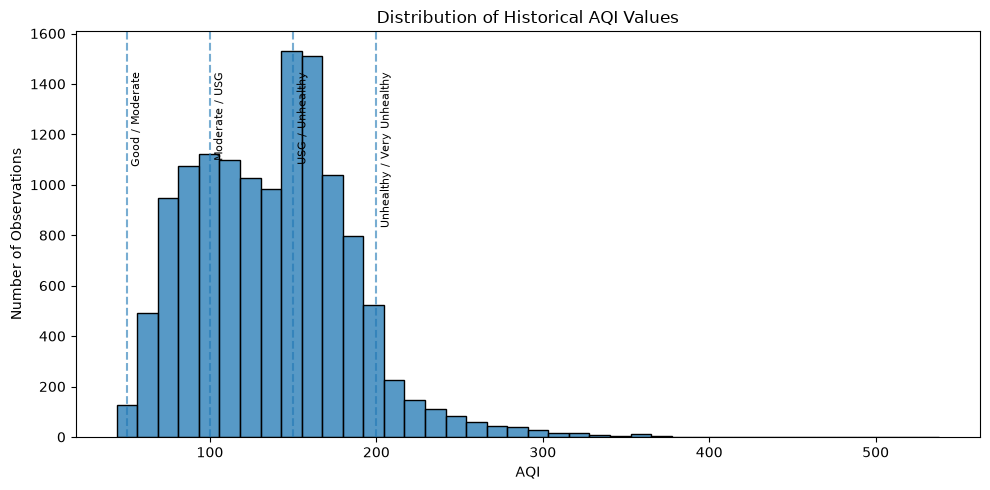

In [ ]:

fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(
    df["aqi"].dropna(),
    bins=40,
    ax=ax
)

# AQI thresholds
thresholds = [
    (50, "Good / Moderate"),
    (100, "Moderate / USG"),
    (150, "USG / Unhealthy"),
    (200, "Unhealthy / Very Unhealthy"),
]

for x, label in thresholds:

    ax.axvline(
        x,
        linestyle="--",
        alpha=0.6
    )

    ax.text(
        x + 2,
        ax.get_ylim()[1] * 0.90,
        label,
        rotation=90,
        fontsize=8,
        va="top"
    )

ax.set_title(
    "Distribution of Historical AQI Values"
)

ax.set_xlabel("AQI")
ax.set_ylabel("Number of Observations")

plt.tight_layout()
plt.show()

## AQI DISTRIBUTION BY CITY 


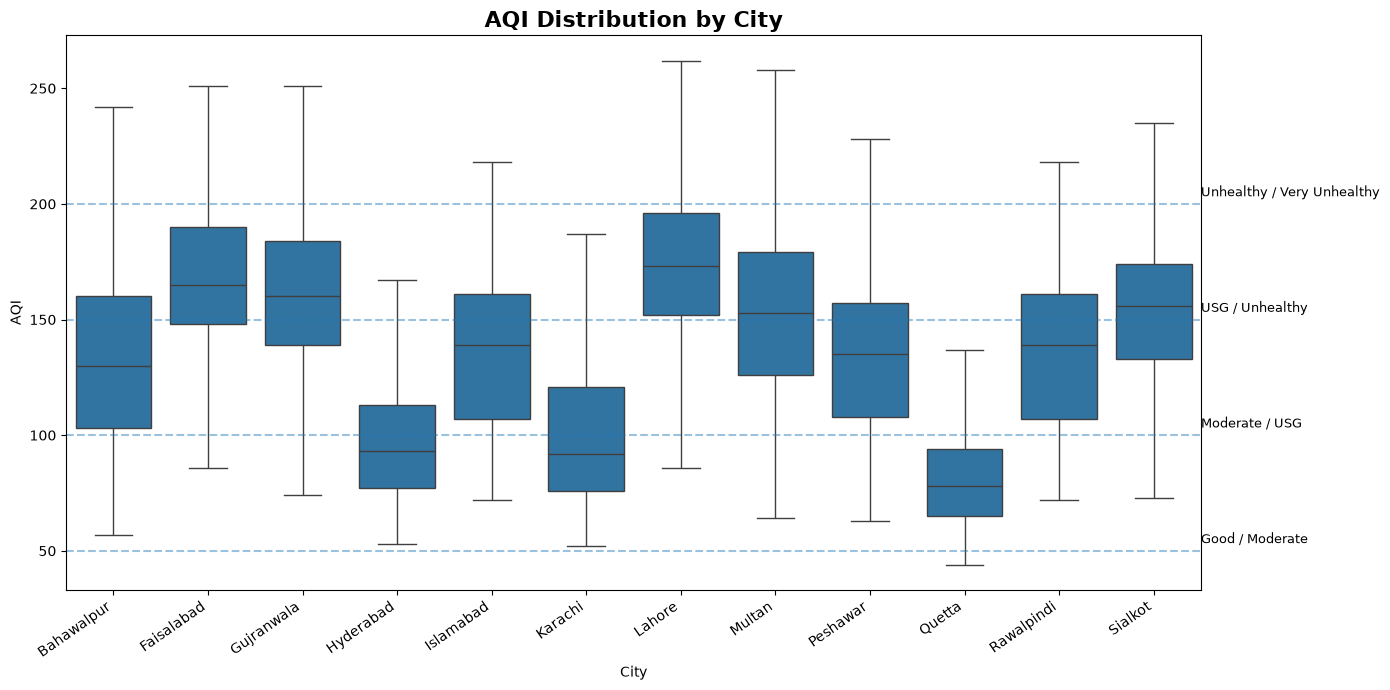

In [ ]:

plt.figure(figsize=(14, 7))

ax = sns.boxplot(
    data=df,
    x="city_name",
    y="aqi",
    showfliers=False
)

# AQI category thresholds
for y, label in [
    (50, "Good / Moderate"),
    (100, "Moderate / USG"),
    (150, "USG / Unhealthy"),
    (200, "Unhealthy / Very Unhealthy"),
]:
    ax.axhline(
        y,
        linestyle="--",
        alpha=0.45
    )

    ax.text(
        len(df["city_name"].unique()) - 0.5,
        y + 2,
        label,
        fontsize=9,
        va="bottom"
    )

ax.set_title(
    "AQI Distribution by City",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("City")
ax.set_ylabel("AQI")

plt.xticks(
    rotation=35,
    ha="right"
)

plt.tight_layout()
plt.show()

## CITY-WISE AVERAGE AQI RANKING


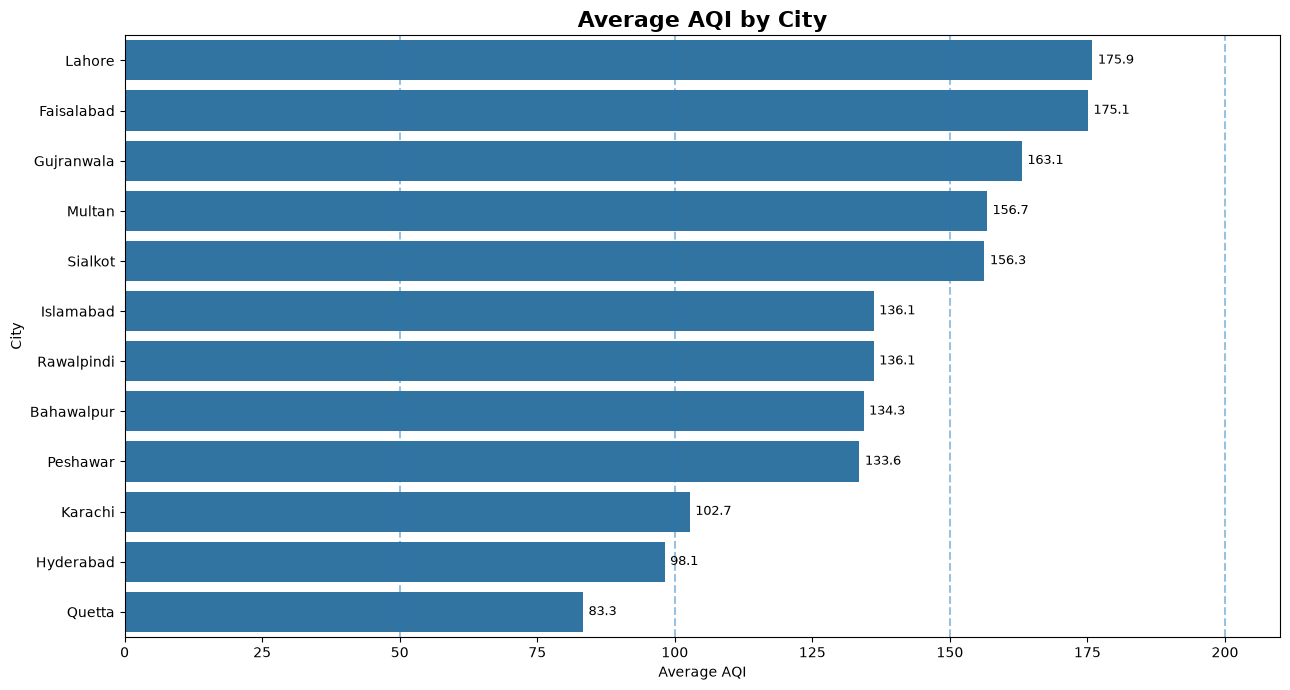

In [ ]:

city_avg = (
    df.groupby("city_name", as_index=False)["aqi"]
      .mean()
      .sort_values("aqi", ascending=False)
)

plt.figure(figsize=(13, 7))

ax = sns.barplot(
    data=city_avg,
    x="aqi",
    y="city_name"
)

# Add values on bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f",
        padding=4,
        fontsize=9
    )

# AQI thresholds
for x in [50, 100, 150, 200]:
    ax.axvline(
        x,
        linestyle="--",
        alpha=0.45
    )

ax.set_title(
    "Average AQI by City",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Average AQI")
ax.set_ylabel("City")

plt.tight_layout()
plt.show()

## DAILY AQI TREND — ALL CITIES


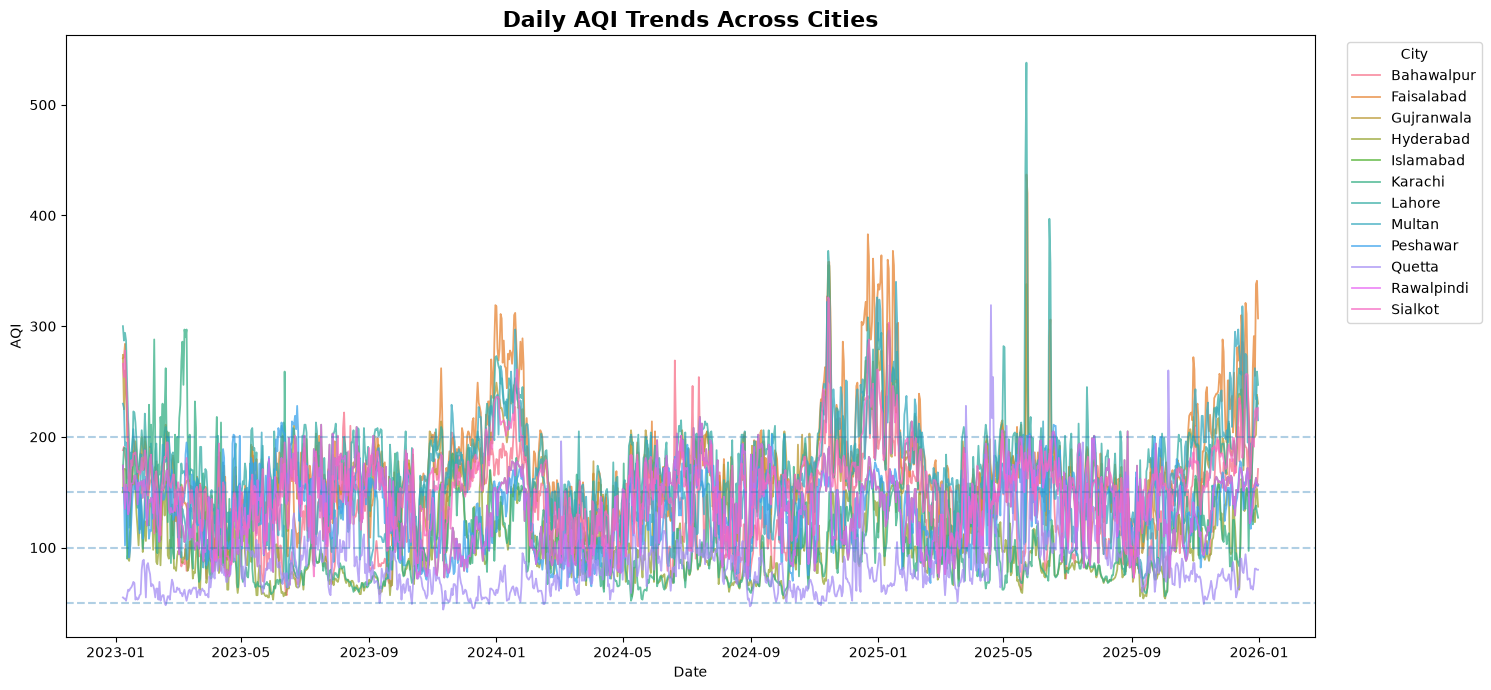

In [ ]:

plt.figure(figsize=(15, 7))

sns.lineplot(
    data=df,
    x="date",
    y="aqi",
    hue="city_name",
    linewidth=1.3,
    alpha=0.75
)

# AQI thresholds
for y in [50, 100, 150, 200]:
    plt.axhline(
        y,
        linestyle="--",
        alpha=0.35
    )

plt.title(
    "Daily AQI Trends Across Cities",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Date")
plt.ylabel("AQI")

plt.legend(
    title="City",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

## AQI + POLLUTANT CORRELATION HEATMAP


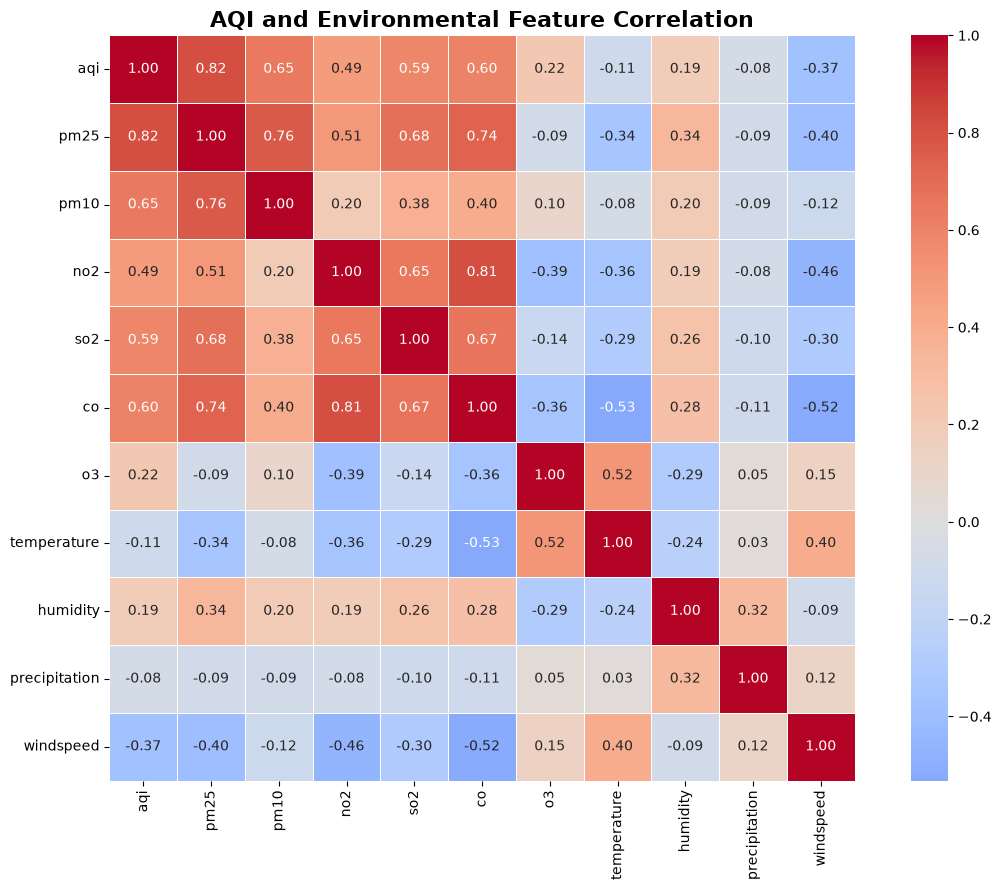

In [ ]:

corr_cols = [
    "aqi",
    "pm25",
    "pm10",
    "no2",
    "so2",
    "co",
    "o3",
    "temperature",
    "humidity",
    "precipitation",
    "windspeed"
]

corr = df[corr_cols].corr()

plt.figure(figsize=(12, 9))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    square=True
)

plt.title(
    "AQI and Environmental Feature Correlation",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

## POLLUTANT DISTRIBUTIONS


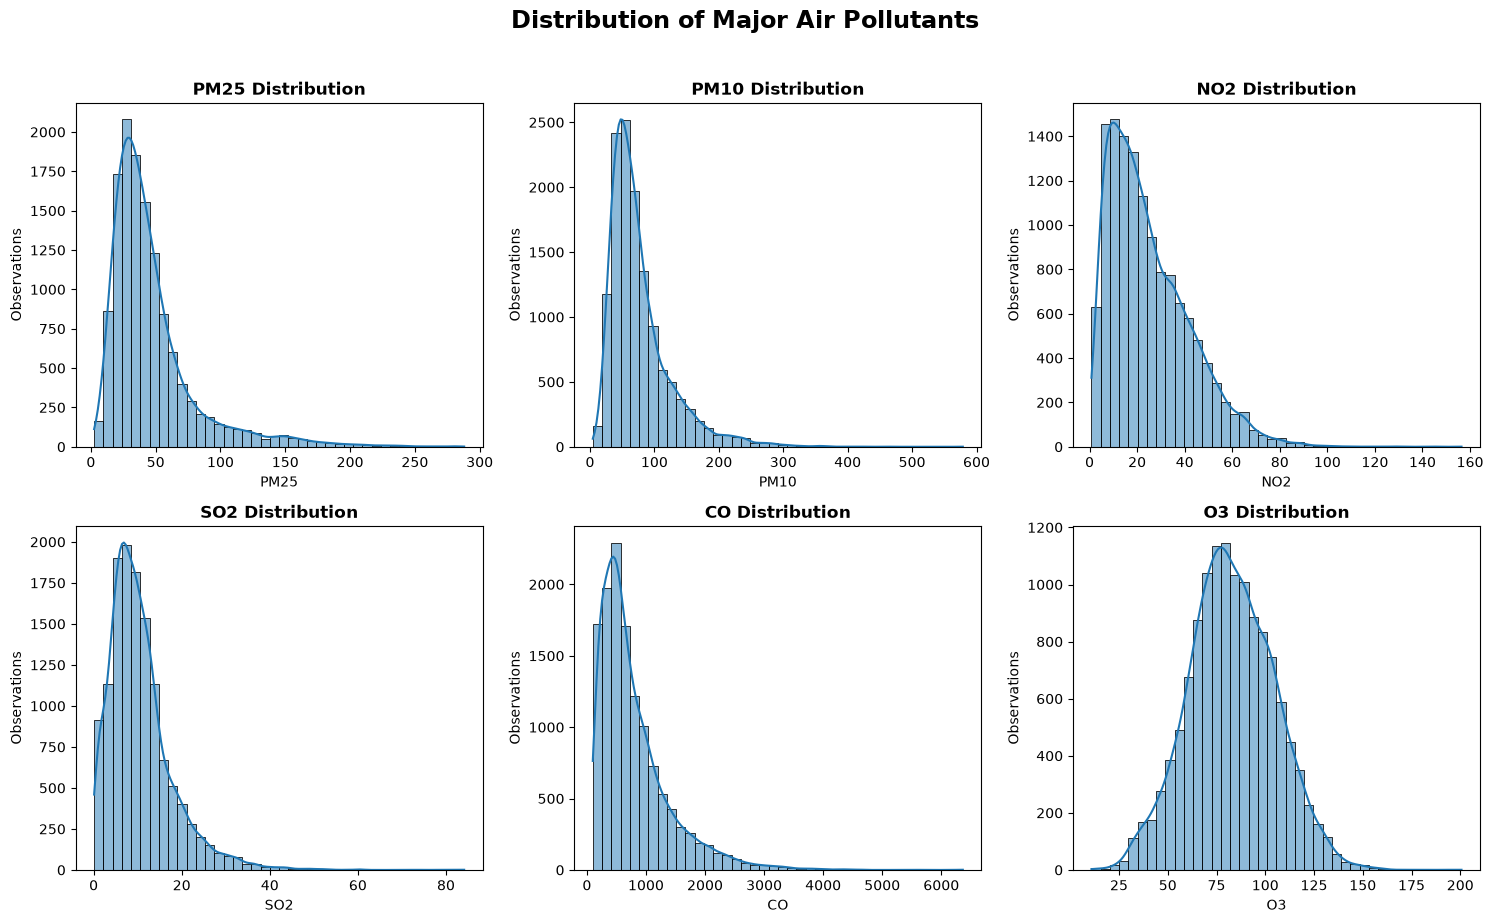

In [ ]:


pollutants = [
    "pm25",
    "pm10",
    "no2",
    "so2",
    "co",
    "o3"
]

fig, axes = plt.subplots(
    2, 3,
    figsize=(15, 9)
)

axes = axes.flatten()

for ax, pollutant in zip(axes, pollutants):

    sns.histplot(
        df[pollutant].dropna(),
        bins=40,
        kde=True,
        ax=ax
    )

    ax.set_title(
        f"{pollutant.upper()} Distribution",
        fontweight="bold"
    )

    ax.set_xlabel(pollutant.upper())
    ax.set_ylabel("Observations")

plt.suptitle(
    "Distribution of Major Air Pollutants",
    fontsize=17,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()
plt.show()

## AQI CATEGORY DISTRIBUTION

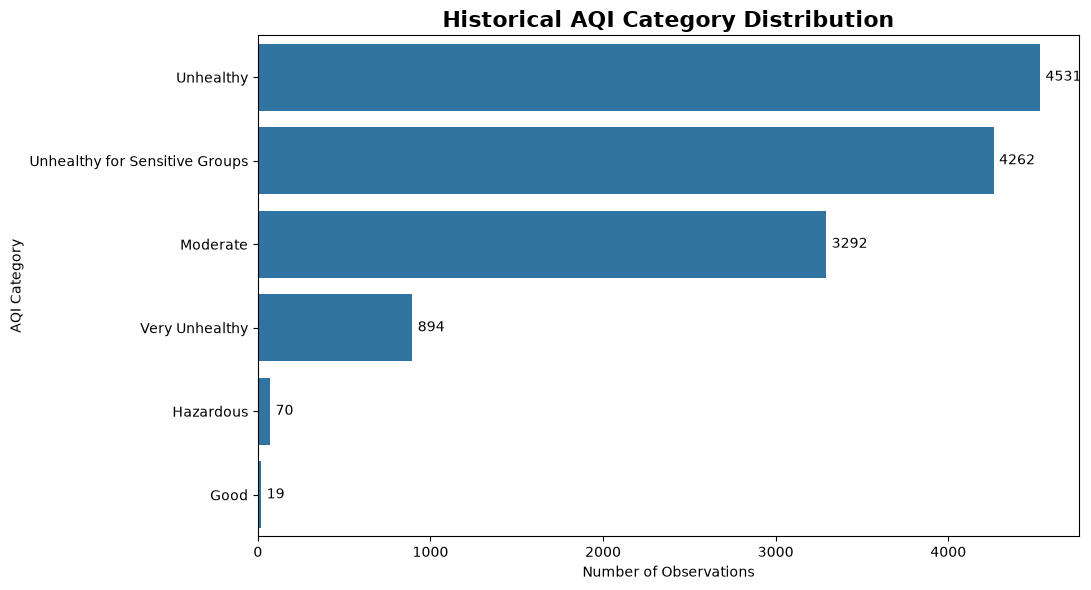

In [ ]:

category_counts = (
    df["aqi_category"]
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(11, 6))

ax = sns.barplot(
    x=category_counts.values,
    y=category_counts.index
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%d",
        padding=4
    )

plt.title(
    "Historical AQI Category Distribution",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Number of Observations")
plt.ylabel("AQI Category")

plt.tight_layout()
plt.show()

## AQI vs MAJOR POLLUTANTS

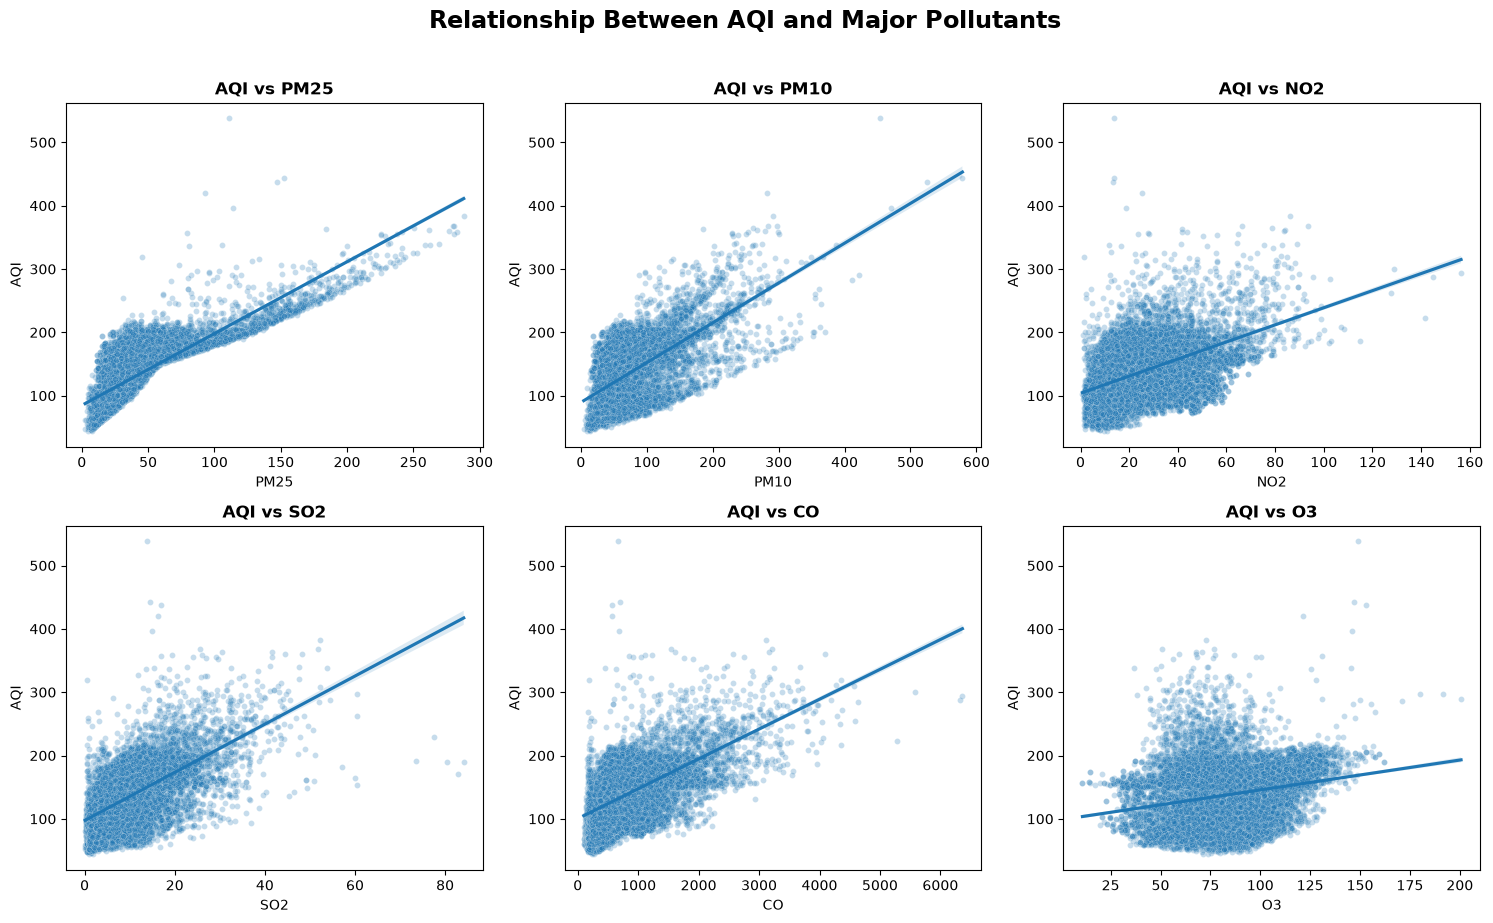

In [ ]:

pollutants = ["pm25", "pm10", "no2", "so2", "co", "o3"]

fig, axes = plt.subplots(
    2, 3,
    figsize=(15, 9)
)

axes = axes.flatten()

for ax, pollutant in zip(axes, pollutants):

    sns.scatterplot(
        data=df,
        x=pollutant,
        y="aqi",
        alpha=0.25,
        s=18,
        ax=ax
    )

    # Trend line
    sns.regplot(
        data=df,
        x=pollutant,
        y="aqi",
        scatter=False,
        ax=ax
    )

    ax.set_title(
        f"AQI vs {pollutant.upper()}",
        fontweight="bold"
    )

    ax.set_xlabel(pollutant.upper())
    ax.set_ylabel("AQI")

plt.suptitle(
    "Relationship Between AQI and Major Pollutants",
    fontsize=17,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()
plt.show()

## AQI CATEGORY DISTRIBUTION BY CITY


<Figure size 1400x700 with 0 Axes>

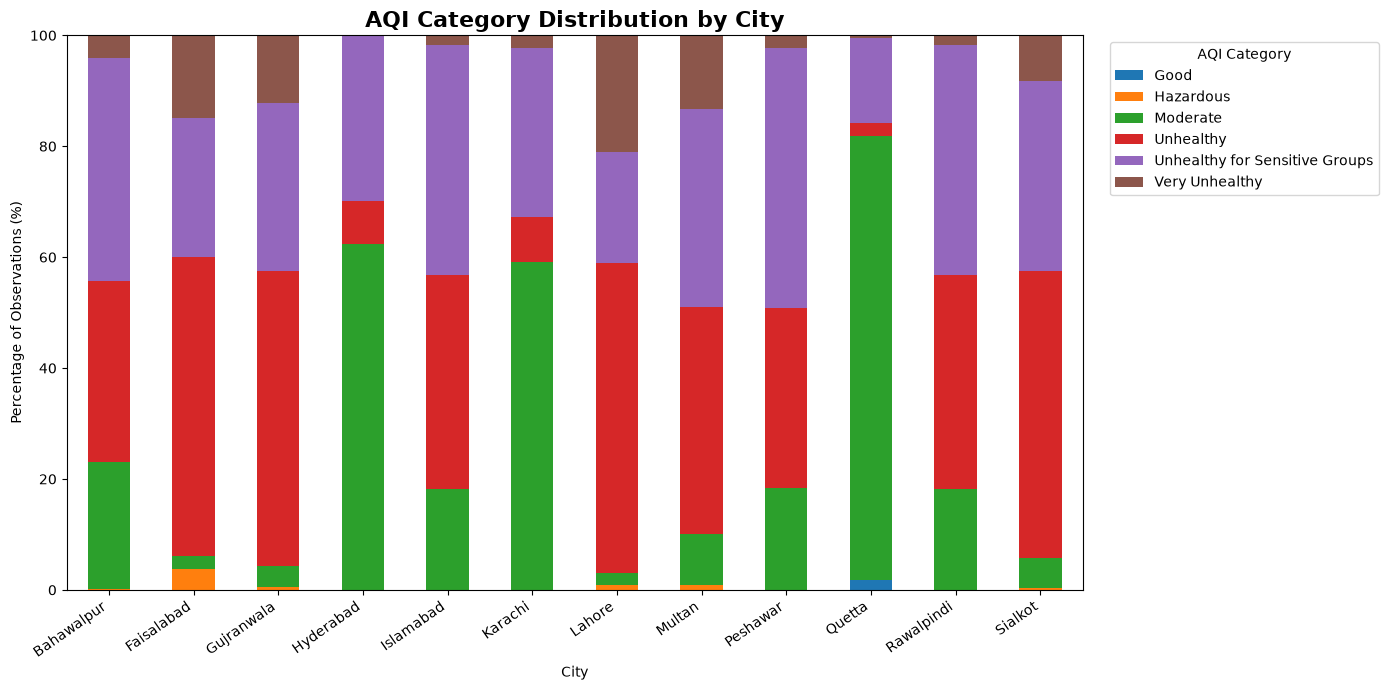

In [ ]:

category_city = pd.crosstab(
    df["city_name"],
    df["aqi_category"],
    normalize="index"
) * 100

plt.figure(figsize=(14, 7))

ax = category_city.plot(
    kind="bar",
    stacked=True,
    figsize=(14, 7)
)

ax.set_title(
    "AQI Category Distribution by City",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("City")
ax.set_ylabel("Percentage of Observations (%)")

plt.xticks(
    rotation=35,
    ha="right"
)

plt.legend(
    title="AQI Category",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

## MONTHLY AQI PATTERN


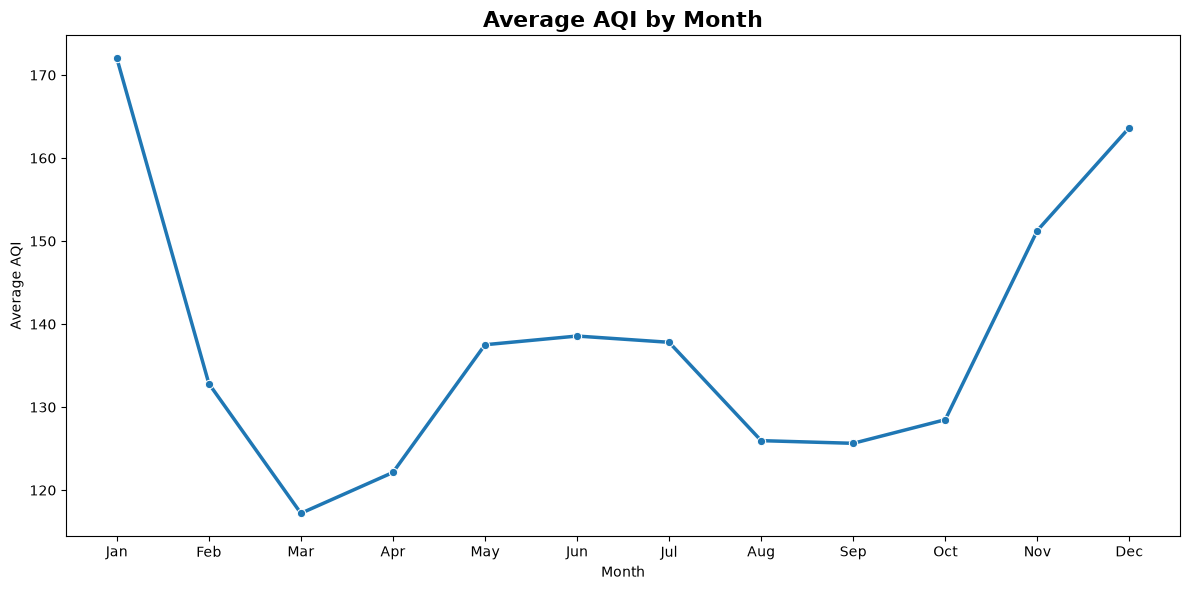

In [ ]:

monthly_aqi = (
    df.assign(
        month=df["date"].dt.month,
        month_name=df["date"].dt.strftime("%b")
    )
    .groupby(["month", "month_name"], as_index=False)["aqi"]
    .mean()
    .sort_values("month")
)

plt.figure(figsize=(12, 6))

ax = sns.lineplot(
    data=monthly_aqi,
    x="month_name",
    y="aqi",
    marker="o",
    linewidth=2.5
)

plt.title(
    "Average AQI by Month",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Month")
plt.ylabel("Average AQI")

plt.tight_layout()
plt.show()

## LOAD PREDICTION ANALYSIS


In [ ]:

PREDICTION_PATH = (
    PROJECT_ROOT
    / "analytics"
    / "prediction_analysis.csv"
)

prediction_df = pd.read_csv(
    PREDICTION_PATH
)

prediction_df["date"] = pd.to_datetime(
    prediction_df["date"],
    errors="coerce"
)

print("=" * 70)
print("PREDICTION ANALYSIS")
print("=" * 70)

print("Shape:", prediction_df.shape)

print()
print("Columns:")
print(prediction_df.columns.tolist())

print()
print(prediction_df.describe())

PREDICTION ANALYSIS
Shape: (2616, 12)

Columns:
['city_name', 'date', 'aqi', 'target_aqi', 'prediction', 'absolute_error', 'error', 'prediction_category', 'actual_category', 'actual_change', 'predicted_change', 'change_error']

                      date          aqi   target_aqi   prediction  \
count                 2616  2616.000000  2616.000000  2616.000000   
mean   2026-04-19 12:00:00   141.475917   141.399847   140.979049   
min    2026-01-01 00:00:00    54.000000    54.000000    58.536674   
25%    2026-02-24 00:00:00   103.000000   103.000000   109.440849   
50%    2026-04-19 12:00:00   142.000000   142.000000   138.907870   
75%    2026-06-13 00:00:00   166.000000   166.250000   165.506158   
max    2026-08-06 00:00:00   371.000000   371.000000   346.136400   
std                    NaN    47.631836    47.576139    42.731789   

       absolute_error        error  actual_change  predicted_change  \
count     2616.000000  2616.000000    2616.000000       2616.000000   
mean    

## ACTUAL vs PREDICTED AQI


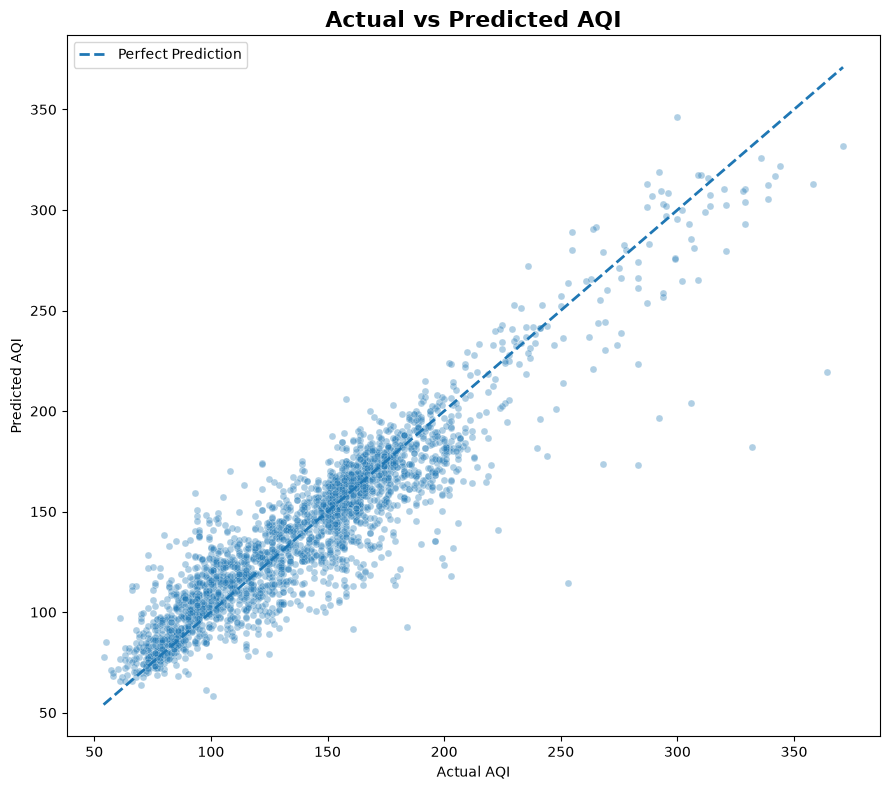

In [ ]:

plt.figure(figsize=(9, 8))

sns.scatterplot(
    data=prediction_df,
    x="target_aqi",
    y="prediction",
    alpha=0.35,
    s=25
)

# Perfect prediction line
min_aqi = min(
    prediction_df["target_aqi"].min(),
    prediction_df["prediction"].min()
)

max_aqi = max(
    prediction_df["target_aqi"].max(),
    prediction_df["prediction"].max()
)

plt.plot(
    [min_aqi, max_aqi],
    [min_aqi, max_aqi],
    linestyle="--",
    linewidth=2,
    label="Perfect Prediction"
)

plt.title(
    "Actual vs Predicted AQI",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")

plt.legend()

plt.tight_layout()
plt.show()

## PREDICTION ERROR DISTRIBUTION


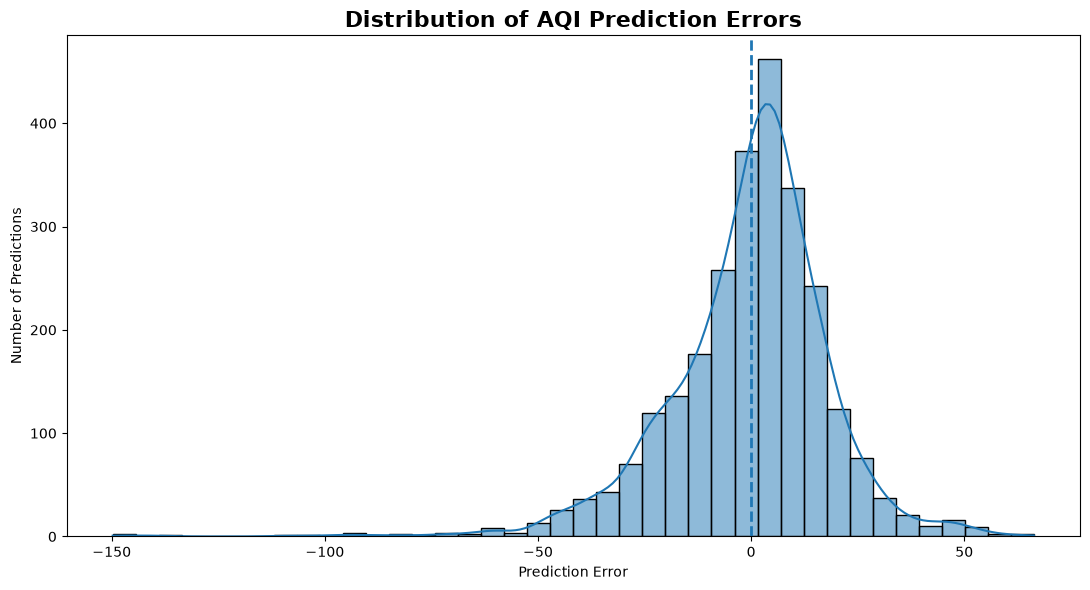

In [ ]:


plt.figure(figsize=(11, 6))

sns.histplot(
    prediction_df["error"].dropna(),
    bins=40,
    kde=True
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=2
)

plt.title(
    "Distribution of AQI Prediction Errors",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Prediction Error")
plt.ylabel("Number of Predictions")

plt.tight_layout()
plt.show()

## PREDICTION ERROR BY CITY


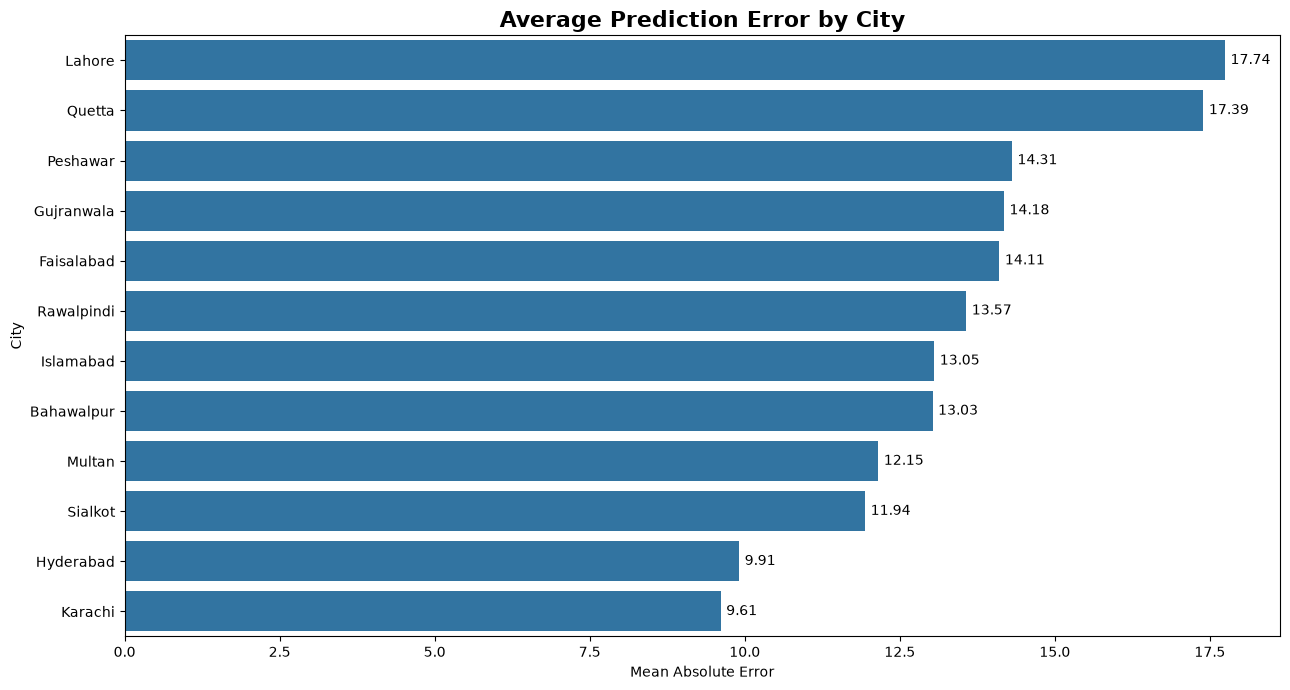

In [ ]:


city_error = (
    prediction_df
    .groupby("city_name")["absolute_error"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(13, 7))

ax = sns.barplot(
    x=city_error.values,
    y=city_error.index
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        padding=4
    )

plt.title(
    "Average Prediction Error by City",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Mean Absolute Error")
plt.ylabel("City")

plt.tight_layout()
plt.show()

# ACTUAL vs PREDICTED AQI CHANGE


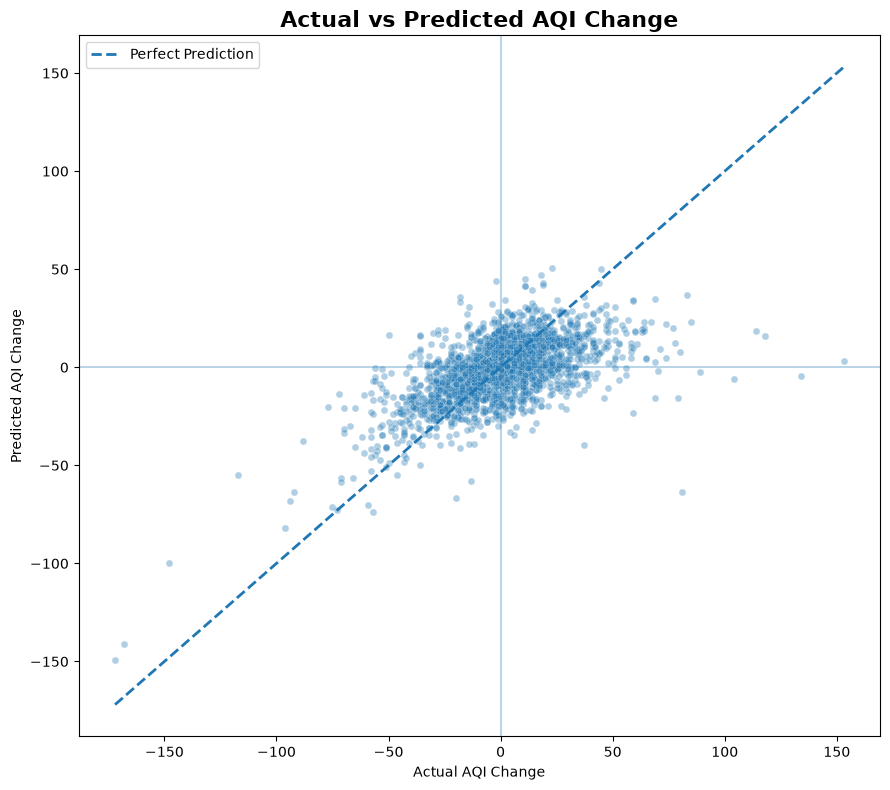

In [ ]:


plt.figure(figsize=(9, 8))

sns.scatterplot(
    data=prediction_df,
    x="actual_change",
    y="predicted_change",
    alpha=0.35,
    s=25
)

min_change = min(
    prediction_df["actual_change"].min(),
    prediction_df["predicted_change"].min()
)

max_change = max(
    prediction_df["actual_change"].max(),
    prediction_df["predicted_change"].max()
)

plt.plot(
    [min_change, max_change],
    [min_change, max_change],
    linestyle="--",
    linewidth=2,
    label="Perfect Prediction"
)

plt.axhline(0, alpha=0.3)
plt.axvline(0, alpha=0.3)

plt.title(
    "Actual vs Predicted AQI Change",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Actual AQI Change")
plt.ylabel("Predicted AQI Change")

plt.legend()

plt.tight_layout()
plt.show()

# MODEL PERFORMANCE


In [ ]:


MODEL_PATH = (
    PROJECT_ROOT
    / "analytics"
    / "model_performance.csv"
)

model_df = pd.read_csv(MODEL_PATH)

print("=" * 70)
print("MODEL PERFORMANCE")
print("=" * 70)

print("Shape:", model_df.shape)

print()
print("Columns:")
print(model_df.columns.tolist())

print()
print(model_df.head())

print()
print("Statistics:")
print(model_df.describe(include="all"))

MODEL PERFORMANCE
Shape: (12, 8)

Columns:
['model', 'rows', 'mae', 'rmse', 'r2', 'within_10', 'within_20', 'within_30']

                model  rows        mae       rmse        r2  within_10  \
0  Production XGBoost  2616  13.416400  18.795000  0.843900      50.69   
1        BASE_XGBOOST  2616  13.416364  18.794957  0.843876        NaN   
2          DELTA_ONLY  2616  13.614695  18.996250  0.840514        NaN   
3     BASE_DELTA_0.10  2616  13.377640  18.722439  0.845078        NaN   
4     BASE_DELTA_0.20  2616  13.352687  18.670368  0.845939        NaN   

   within_20  within_30  
0      78.33      90.98  
1        NaN        NaN  
2        NaN        NaN  
3        NaN        NaN  
4        NaN        NaN  

Statistics:
                     model    rows        mae       rmse         r2  \
count                   12    12.0  12.000000  12.000000  12.000000   
unique                  12     NaN        NaN        NaN        NaN   
top     Production XGBoost     NaN        NaN      

# OVERALL MODEL PERFORMANCE


In [ ]:


import numpy as np

# Keep only rows where actual and predicted AQI exist
evaluation_df = prediction_df[
    ["target_aqi", "prediction"]
].dropna()

actual = evaluation_df["target_aqi"]
predicted = evaluation_df["prediction"]

# ------------------------------------------------------------
# MAE — Mean Absolute Error
# ------------------------------------------------------------

mae = np.mean(
    np.abs(actual - predicted)
)

# ------------------------------------------------------------
# RMSE — Root Mean Squared Error
# ------------------------------------------------------------

rmse = np.sqrt(
    np.mean(
        (actual - predicted) ** 2
    )
)

# ------------------------------------------------------------
# R² — Coefficient of Determination
# ------------------------------------------------------------

ss_res = np.sum(
    (actual - predicted) ** 2
)

ss_tot = np.sum(
    (actual - actual.mean()) ** 2
)

r2 = 1 - (
    ss_res / ss_tot
)

# ------------------------------------------------------------
# RESULTS
# ------------------------------------------------------------

print("=" * 70)
print("MODEL PERFORMANCE")
print("=" * 70)

print(f"Evaluated predictions : {len(evaluation_df):,}")
print(f"MAE                   : {mae:.3f}")
print(f"RMSE                  : {rmse:.3f}")
print(f"R²                    : {r2:.3f}")

MODEL PERFORMANCE
Evaluated predictions : 2,616
MAE                   : 13.416
RMSE                  : 18.795
R²                    : 0.844


In [48]:
metrics = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R²"],
    "Value": [mae, rmse, r2]
})

# MODEL PERFORMANCE METRICS


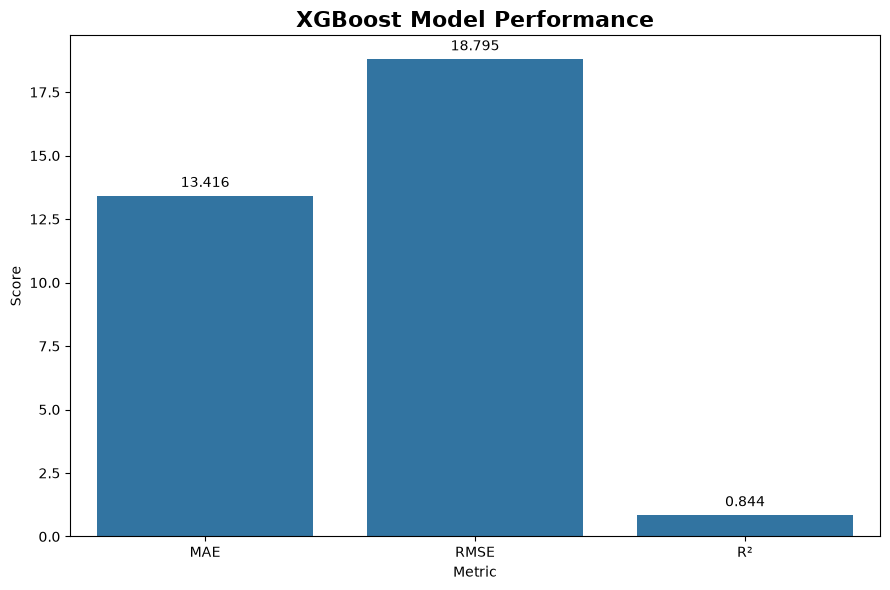

In [ ]:


metrics = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R²"],
    "Value": [mae, rmse, r2]
})

plt.figure(figsize=(9, 6))

ax = sns.barplot(
    data=metrics,
    x="Metric",
    y="Value"
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        padding=4
    )

plt.title(
    "XGBoost Model Performance",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Metric")
plt.ylabel("Score")

plt.tight_layout()
plt.show()

# PREDICTION ERROR VS ACTUAL AQI


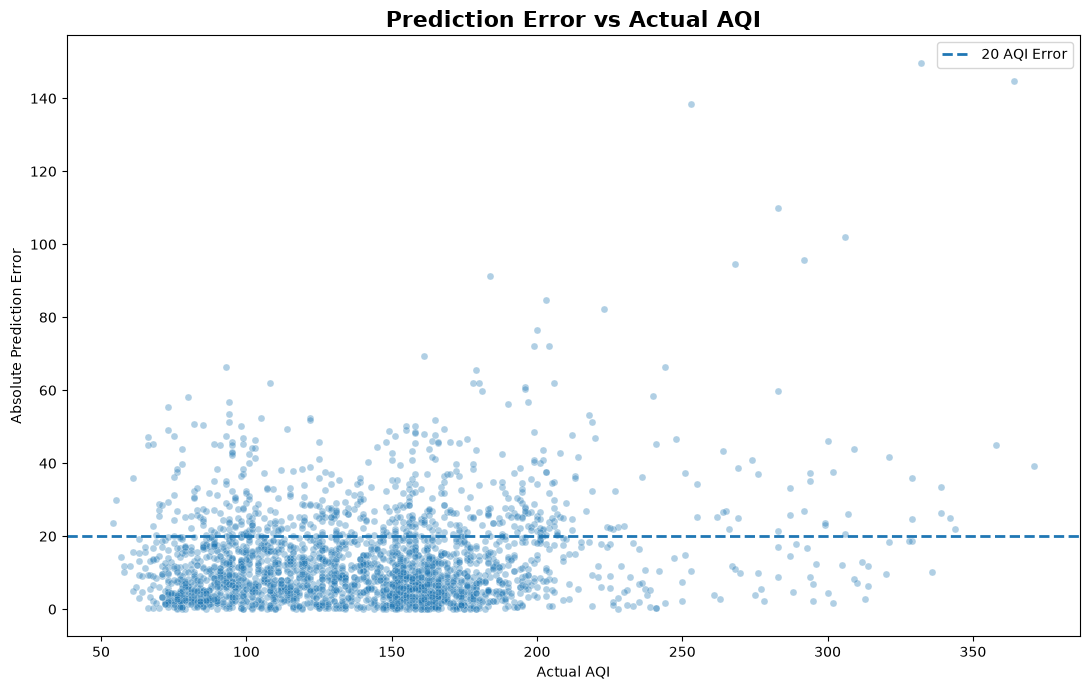

In [ ]:


plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=prediction_df,
    x="target_aqi",
    y="absolute_error",
    alpha=0.35,
    s=25
)

plt.axhline(
    20,
    linestyle="--",
    linewidth=2,
    label="20 AQI Error"
)

plt.title(
    "Prediction Error vs Actual AQI",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Actual AQI")
plt.ylabel("Absolute Prediction Error")

plt.legend()

plt.tight_layout()
plt.show()

# PREDICTION ERROR BY AQI CATEGORY


                                mean_error  median_error  count
actual_category                                                
Hazardous                        32.975348     21.937012     29
Very Unhealthy                   22.590586     18.674767    178
Unhealthy                        12.628034      8.726334    956
Unhealthy for Sensitive Groups   12.491073     10.306763    853
Moderate                         12.320853      9.080570    600


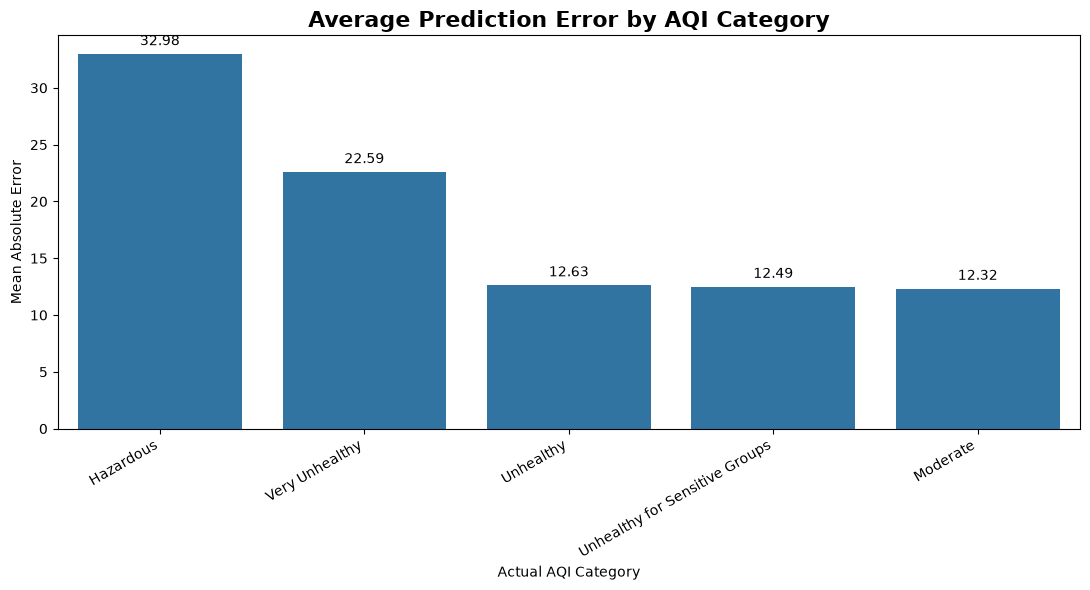

In [ ]:


category_error = (
    prediction_df
    .groupby("actual_category")["absolute_error"]
    .agg(
        mean_error="mean",
        median_error="median",
        count="count"
    )
    .sort_values(
        "mean_error",
        ascending=False
    )
)

print(category_error)

plt.figure(figsize=(11, 6))

ax = sns.barplot(
    data=category_error.reset_index(),
    x="actual_category",
    y="mean_error"
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        padding=4
    )

plt.title(
    "Average Prediction Error by AQI Category",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Actual AQI Category")
plt.ylabel("Mean Absolute Error")

plt.xticks(
    rotation=30,
    ha="right"
)

plt.tight_layout()
plt.show()

# PREDICTION ERROR DISTRIBUTION BY CITY


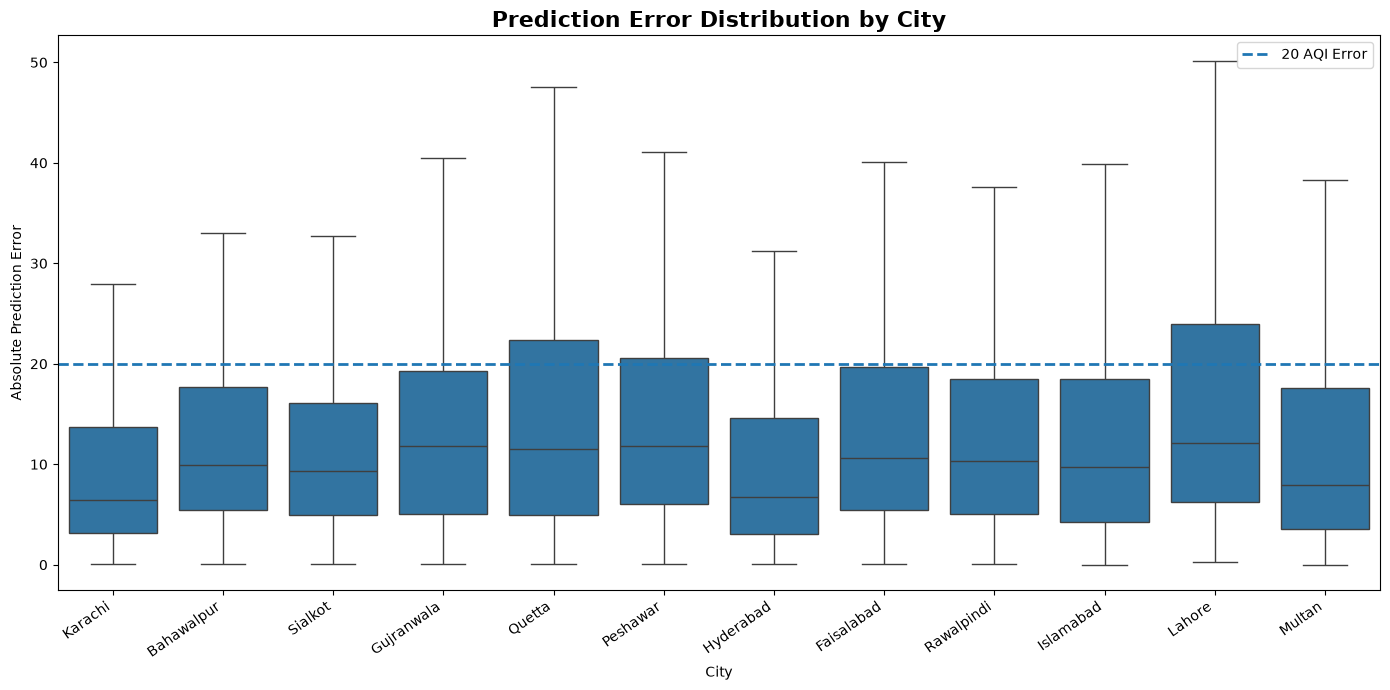

In [ ]:

plt.figure(figsize=(14, 7))

sns.boxplot(
    data=prediction_df,
    x="city_name",
    y="absolute_error",
    showfliers=False
)

plt.axhline(
    20,
    linestyle="--",
    linewidth=2,
    label="20 AQI Error"
)

plt.title(
    "Prediction Error Distribution by City",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("City")
plt.ylabel("Absolute Prediction Error")

plt.xticks(
    rotation=35,
    ha="right"
)

plt.legend()

plt.tight_layout()
plt.show()

# FORECAST PERFORMANCE BY HORIZON


In [ ]:


horizon_error = (
    prediction_df
    .groupby("date")
    .agg(
        mae=("absolute_error", "mean"),
        mean_error=("error", "mean"),
        predictions=("prediction", "count")
    )
)

print(horizon_error)

                  mae  mean_error  predictions
date                                          
2026-01-01  17.152004  -16.514780           12
2026-01-02  10.661317    9.407543           12
2026-01-03  13.678317   -6.885383           12
2026-01-04  14.555466   -8.294291           12
2026-01-05   9.151054   -1.217585           12
...               ...         ...          ...
2026-08-02   7.873475   -0.562782           12
2026-08-03  28.117635  -21.315810           12
2026-08-04   8.620868   -0.082052           12
2026-08-05  14.740856  -10.027543           12
2026-08-06  12.545512   -8.708229           12

[218 rows x 3 columns]


# DATA QUALITY SUMMARY


In [ ]:


quality = pd.DataFrame({
    "Column": df.columns,
    "Missing": df.isna().sum().values,
    "Missing_%": (
        df.isna().mean().values * 100
    ),
    "Unique": df.nunique().values
})

quality = quality.sort_values(
    "Missing_%",
    ascending=False
)

print("=" * 70)
print("DATA QUALITY SUMMARY")
print("=" * 70)

print(
    quality.to_string(index=False)
)

DATA QUALITY SUMMARY
       Column  Missing  Missing_%  Unique
      city_id        0        0.0      12
    city_name        0        0.0      12
         date        0        0.0    1089
          aqi        0        0.0     296
         pm25        0        0.0    8918
         pm10        0        0.0    9937
          no2        0        0.0    7681
          so2        0        0.0    5109
           co        0        0.0   10343
           o3        0        0.0    2380
  temperature        0        0.0     394
     humidity        0        0.0      91
precipitation        0        0.0     382
    windspeed        0        0.0     363
 aqi_category        0        0.0       6


# MISSING VALUES


In [ ]:


missing = (
    df.isna()
      .sum()
      .sort_values(ascending=False)
)

missing = missing[missing > 0]

if len(missing) == 0:

    print("No missing values found.")

else:

    plt.figure(figsize=(11, 6))

    ax = sns.barplot(
        x=missing.values,
        y=missing.index
    )

    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%d",
            padding=4
        )

    plt.title(
        "Missing Values by Feature",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Number of Missing Values")
    plt.ylabel("Feature")

    plt.tight_layout()
    plt.show()

No missing values found.


# POLLUTANT RELATIONSHIP WITH AQI


In [ ]:

pollutants = [
    "pm25",
    "pm10",
    "no2",
    "so2",
    "co",
    "o3"
]

pollutant_corr = (
    df[pollutants + ["aqi"]]
    .corr()["aqi"]
    .drop("aqi")
    .sort_values(ascending=False)
)

print("=" * 70)
print("POLLUTANT CORRELATION WITH AQI")
print("=" * 70)

print(
    pollutant_corr.to_string()
)

POLLUTANT CORRELATION WITH AQI
pm25    0.815704
pm10    0.645647
co      0.604199
so2     0.592285
no2     0.486849
o3      0.221538


# POLLUTANT CORRELATION WITH AQI — VISUAL


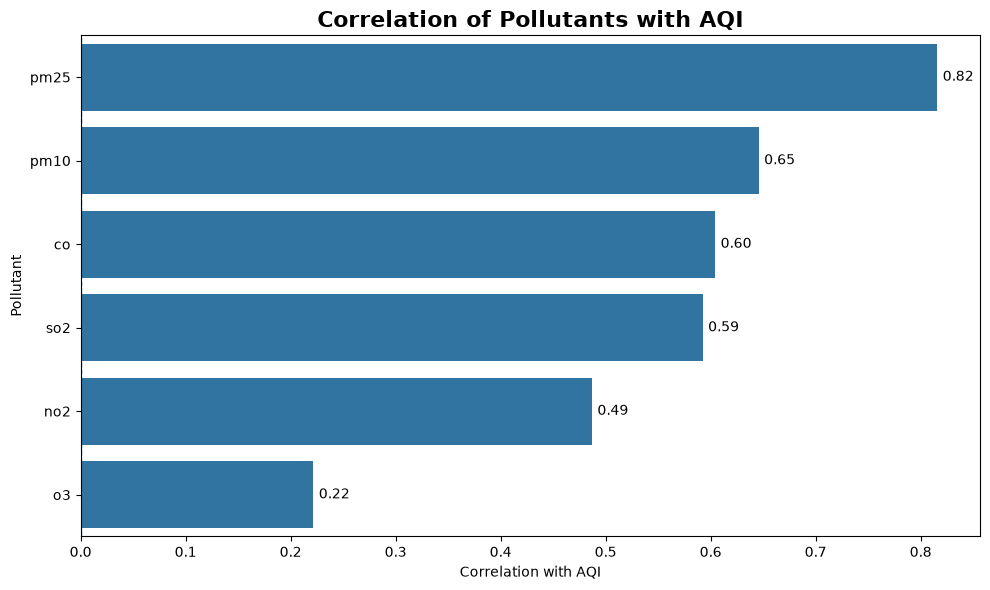

In [ ]:


plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=pollutant_corr.values,
    y=pollutant_corr.index
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        padding=4
    )

plt.axvline(
    0,
    linestyle="--",
    linewidth=1
)

plt.title(
    "Correlation of Pollutants with AQI",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Correlation with AQI")
plt.ylabel("Pollutant")

plt.tight_layout()
plt.show()

# AQI VS MAJOR POLLUTANTS


Top 3 pollutants by absolute correlation:
['pm25', 'pm10', 'co']


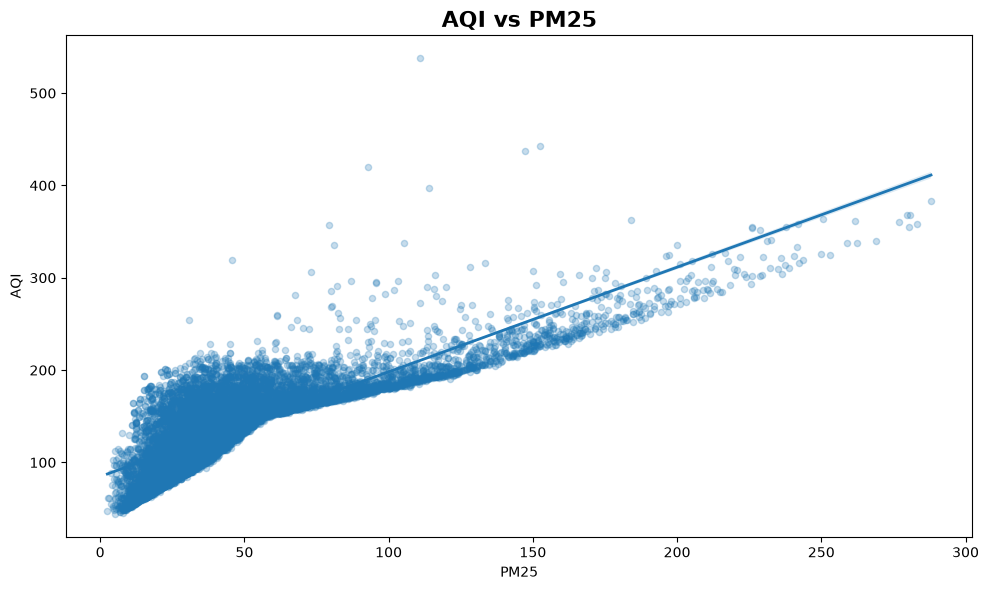

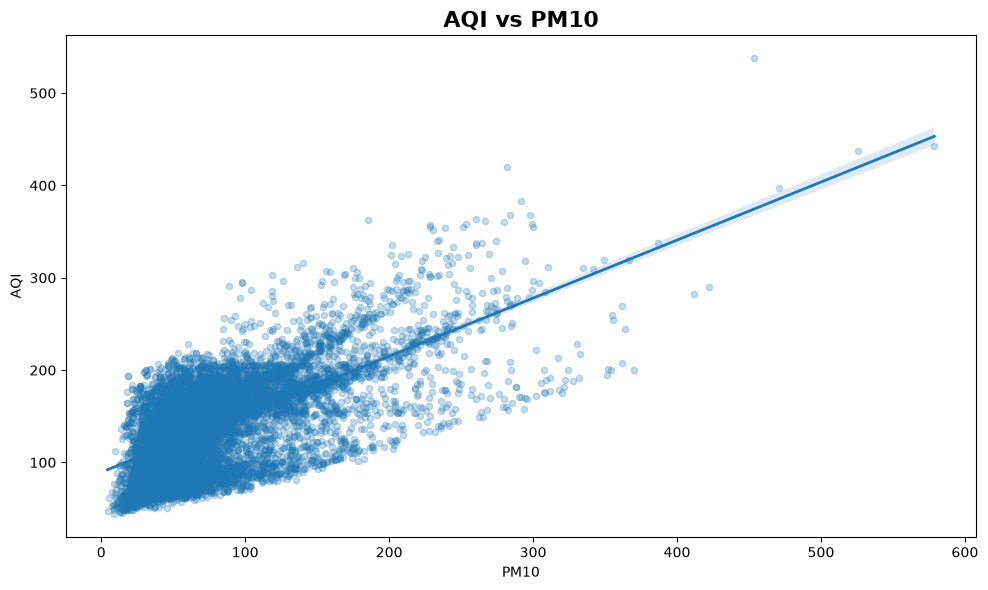

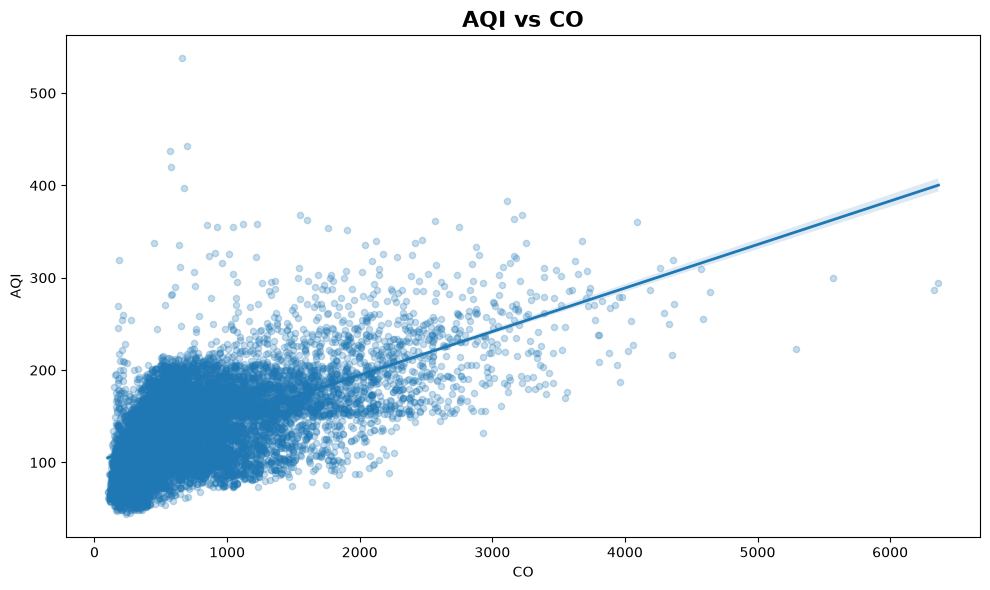

In [ ]:


top_pollutants = (
    pollutant_corr.abs()
    .sort_values(ascending=False)
    .head(3)
    .index
)

print("Top 3 pollutants by absolute correlation:")
print(list(top_pollutants))

for pollutant in top_pollutants:

    plt.figure(figsize=(10, 6))

    sns.regplot(
        data=df,
        x=pollutant,
        y="aqi",
        scatter_kws={
            "alpha": 0.25,
            "s": 20
        },
        line_kws={
            "linewidth": 2
        }
    )

    plt.title(
        f"AQI vs {pollutant.upper()}",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel(pollutant.upper())
    plt.ylabel("AQI")

    plt.tight_layout()
    plt.show()

In [61]:
from pathlib import Path
import sys

PROJECT_ROOT = Path(r"C:\Users\warda\Downloads\aqi-predictor-v4")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)
print("Exists:", PROJECT_ROOT.exists())
print("src exists:", (PROJECT_ROOT / "src").exists())
print("database exists:", (PROJECT_ROOT / "src" / "database").exists())

Project root: C:\Users\warda\Downloads\aqi-predictor-v4
Exists: True
src exists: True
database exists: True


In [62]:
import os

os.chdir(PROJECT_ROOT)

print("Current directory:")
print(Path.cwd())

Current directory:
C:\Users\warda\Downloads\aqi-predictor-v4


# LOAD FORECAST HISTORY


In [ ]:


from pathlib import Path
import sys
import numpy as np
import pandas as pd

PROJECT_ROOT = Path(r"C:\Users\warda\Downloads\aqi-predictor-v4")

# Make project modules available
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Import database connection
import subprocess
import sys

# Install duckdb if not already installed
subprocess.check_call([sys.executable, "-m", "pip", "install", "duckdb", "-q"])

from src.database.connection import get_connection

conn = get_connection()

forecast_df = conn.execute("""
    SELECT
        city_name,
        origin_date,
        forecast_date,
        horizon,
        predicted_aqi,
        actual_aqi,
        error,
        absolute_error,
        model_name
    FROM forecast_predictions
""").fetchdf()

conn.close()

print("=" * 70)
print("FORECAST HISTORY LOADED")
print("=" * 70)

print("Shape:", forecast_df.shape)

print()
print("Horizons:")
print(sorted(forecast_df["horizon"].dropna().unique()))

print()
print("Rows with actual AQI:",
      forecast_df["actual_aqi"].notna().sum())

print()
print(forecast_df.head())

FORECAST HISTORY LOADED
Shape: (396, 9)

Horizons:
[np.int32(1), np.int32(2), np.int32(3)]

Rows with actual AQI: 324

  city_name origin_date forecast_date  horizon  predicted_aqi  actual_aqi  \
0   Karachi  2026-08-15    2026-08-16        1          70.90        71.0   
1   Karachi  2026-08-15    2026-08-17        2          69.93        70.0   
2   Karachi  2026-08-15    2026-08-18        3          69.11        70.0   
3    Lahore  2026-08-15    2026-08-16        1         158.45       150.5   
4    Lahore  2026-08-15    2026-08-17        2         158.13       136.0   

   error  absolute_error            model_name  
0  -0.10            0.10  PearlsAQI-V9-XGBoost  
1  -0.07            0.07  PearlsAQI-V9-XGBoost  
2  -0.89            0.89  PearlsAQI-V9-XGBoost  
3   7.95            7.95  PearlsAQI-V9-XGBoost  
4  22.13           22.13  PearlsAQI-V9-XGBoost  


# FORECAST PERFORMANCE BY HORIZON


In [ ]:


evaluated = forecast_df.dropna(
    subset=["actual_aqi"]
).copy()

horizon_metrics = (
    evaluated
    .groupby("horizon")
    .agg(
        forecasts=("predicted_aqi", "count"),
        MAE=("absolute_error", "mean"),
        RMSE=(
            "error",
            lambda x: np.sqrt(np.mean(x ** 2))
        ),
        Bias=("error", "mean")
    )
    .reset_index()
    .sort_values("horizon")
)

print("=" * 70)
print("FORECAST PERFORMANCE BY HORIZON")
print("=" * 70)

print(
    horizon_metrics.to_string(index=False)
)

FORECAST PERFORMANCE BY HORIZON
 horizon  forecasts       MAE      RMSE      Bias
       1         84 11.125595 14.564951 -0.058532
       2        120 23.233097 30.484448  7.985764
       3        120 31.132389 38.170865 16.303583


# FORECAST MAE BY HORIZON


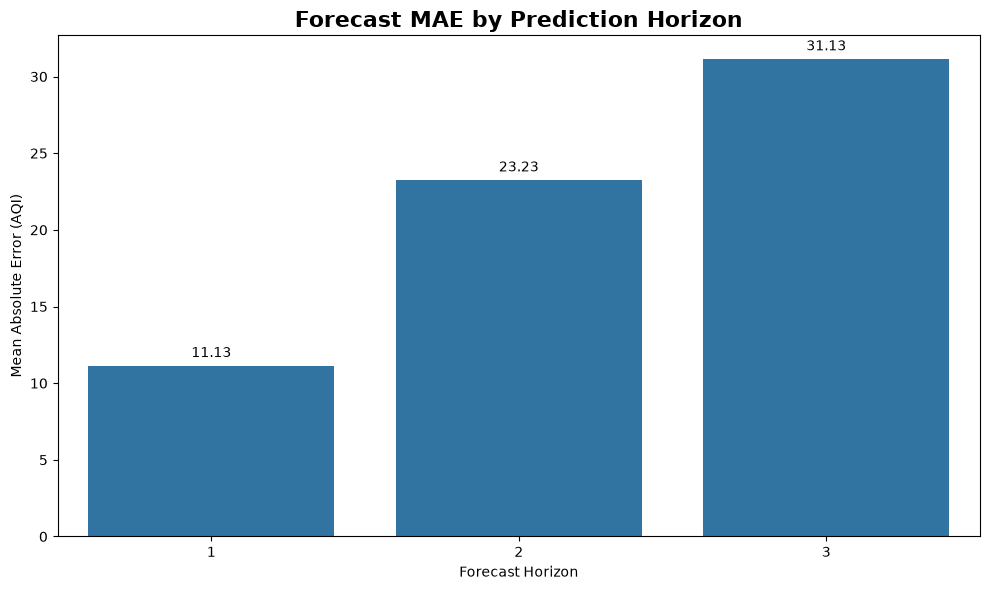

In [ ]:


plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=horizon_metrics,
    x="horizon",
    y="MAE"
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        padding=4
    )

plt.title(
    "Forecast MAE by Prediction Horizon",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Forecast Horizon")
plt.ylabel("Mean Absolute Error (AQI)")

plt.tight_layout()
plt.show()

# FINAL EDA SUMMARY


In [ ]:


# Basic dataset information
total_rows = len(df)
total_cities = df["city_name"].nunique()

aqi_min = df["aqi"].min()
aqi_max = df["aqi"].max()
aqi_mean = df["aqi"].mean()
aqi_median = df["aqi"].median()

# City with highest average AQI
city_avg = (
    df.groupby("city_name")["aqi"]
      .mean()
      .sort_values(ascending=False)
)

highest_city = city_avg.index[0]
highest_city_aqi = city_avg.iloc[0]

# City with lowest average AQI
lowest_city = city_avg.index[-1]
lowest_city_aqi = city_avg.iloc[-1]

# Strongest pollutant correlation
strongest_pollutant = pollutant_corr.abs().idxmax()
strongest_corr = pollutant_corr[strongest_pollutant]

# Best / worst forecast horizons
best_horizon = (
    horizon_metrics.loc[
        horizon_metrics["MAE"].idxmin(),
        "horizon"
    ]
)

worst_horizon = (
    horizon_metrics.loc[
        horizon_metrics["MAE"].idxmax(),
        "horizon"
    ]
)

summary = pd.DataFrame({
    "Metric": [
        "Total observations",
        "Number of cities",
        "Minimum AQI",
        "Maximum AQI",
        "Mean AQI",
        "Median AQI",
        "Highest-average-AQI city",
        "Highest city average AQI",
        "Lowest-average-AQI city",
        "Lowest city average AQI",
        "Strongest AQI-related pollutant",
        "Pollutant correlation",
        "Overall MAE",
        "Overall RMSE",
        "Overall R²",
        "Best forecast horizon",
        "Worst forecast horizon"
    ],

    "Value": [
        total_rows,
        total_cities,
        round(aqi_min, 2),
        round(aqi_max, 2),
        round(aqi_mean, 2),
        round(aqi_median, 2),
        highest_city,
        round(highest_city_aqi, 2),
        lowest_city,
        round(lowest_city_aqi, 2),
        strongest_pollutant.upper(),
        round(strongest_corr, 3),
        round(mae, 3),
        round(rmse, 3),
        round(r2, 3),
        int(best_horizon),
        int(worst_horizon)
    ]
})

print("=" * 70)
print("FINAL EDA SUMMARY")
print("=" * 70)

print(
    summary.to_string(index=False)
)

FINAL EDA SUMMARY
                         Metric   Value
             Total observations   13068
               Number of cities      12
                    Minimum AQI    44.0
                    Maximum AQI   538.0
                       Mean AQI  137.61
                     Median AQI   138.0
       Highest-average-AQI city  Lahore
       Highest city average AQI  175.88
        Lowest-average-AQI city  Quetta
        Lowest city average AQI    83.3
Strongest AQI-related pollutant    PM25
          Pollutant correlation   0.816
                    Overall MAE  13.416
                   Overall RMSE  18.795
                     Overall R²   0.844
          Best forecast horizon       1
         Worst forecast horizon       3


# CITY AQI RANKING


In [ ]:


city_ranking = (
    df.groupby("city_name")
      .agg(
          average_aqi=("aqi", "mean"),
          median_aqi=("aqi", "median"),
          minimum_aqi=("aqi", "min"),
          maximum_aqi=("aqi", "max"),
          days_recorded=("aqi", "count")
      )
      .sort_values(
          "average_aqi",
          ascending=False
      )
      .reset_index()
)

city_ranking["rank"] = (
    city_ranking["average_aqi"]
    .rank(
        ascending=False,
        method="dense"
    )
    .astype(int)
)

print(
    city_ranking.to_string(index=False)
)

 city_name  average_aqi  median_aqi  minimum_aqi  maximum_aqi  days_recorded  rank
    Lahore   175.883379       173.0         73.0        538.0           1089     1
Faisalabad   175.079890       165.0         78.0        437.0           1089     2
Gujranwala   163.074380       160.0         69.0        355.0           1089     3
    Multan   156.733701       153.0         64.0        340.0           1089     4
   Sialkot   156.271809       156.0         73.0        326.0           1089     5
 Islamabad   136.143251       139.0         72.0        218.0           1089     6
Rawalpindi   136.143251       139.0         72.0        218.0           1089     6
Bahawalpur   134.301194       130.0         57.0        327.0           1089     7
  Peshawar   133.556474       135.0         63.0        228.0           1089     8
   Karachi   102.717172        92.0         52.0        297.0           1089     9
 Hyderabad    98.141414        93.0         53.0        185.0           1089    10
    

In [73]:
# ============================================================
# KEY FINDINGS
# ============================================================

print("=" * 70)
print("KEY EDA FINDINGS")
print("=" * 70)

print(
    f"• Dataset contains {total_rows:,} observations "
    f"across {total_cities} cities."
)

print(
    f"• AQI ranges from {aqi_min:.1f} to {aqi_max:.1f}, "
    f"with a mean of {aqi_mean:.1f}."
)

print(
    f"• {highest_city} has the highest average AQI "
    f"({highest_city_aqi:.1f})."
)

print(
    f"• {lowest_city} has the lowest average AQI "
    f"({lowest_city_aqi:.1f})."
)

print(
    f"• {strongest_pollutant.upper()} shows the strongest "
    f"absolute correlation with AQI ({strongest_corr:.3f})."
)

print(
    f"• Overall prediction MAE is {mae:.2f} AQI points."
)

print(
    f"• Overall prediction RMSE is {rmse:.2f} AQI points."
)

print(
    f"• Overall model R² is {r2:.3f}."
)

print(
    f"• Horizon {int(best_horizon)} has the lowest forecast MAE."
)

print(
    f"• Horizon {int(worst_horizon)} has the highest forecast MAE."
)

print("=" * 70)

KEY EDA FINDINGS
• Dataset contains 13,068 observations across 12 cities.
• AQI ranges from 44.0 to 538.0, with a mean of 137.6.
• Lahore has the highest average AQI (175.9).
• Quetta has the lowest average AQI (83.3).
• PM25 shows the strongest absolute correlation with AQI (0.816).
• Overall prediction MAE is 13.42 AQI points.
• Overall prediction RMSE is 18.79 AQI points.
• Overall model R² is 0.844.
• Horizon 1 has the lowest forecast MAE.
• Horizon 3 has the highest forecast MAE.
